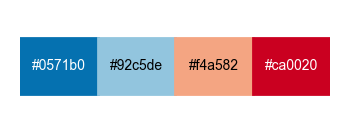

In [20]:
import matplotlib.pyplot as plt

colors = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']
labels = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']

fig, ax = plt.subplots(figsize=(2, 0.6), dpi=200)

for i, (c, lab) in enumerate(zip(colors, labels)):
    # 画色块
    ax.add_patch(plt.Rectangle((i, 0.2), 1, 0.6, color=c))
    
    # 写标签（在色块中间）
    ax.text(i + 0.5, 0.5, lab,
            ha='center', va='center',
            fontsize=5,
            color='white' if i in [0, 3] else 'black')  # 深色用白字更清晰

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

In [21]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2


In [22]:
# 以药物为单位
# 获取不同物种对药物降解比例
# 获取所有物种的EC预测结果
# 获取药物降解的EC列表
# 统计物种对不同EC的酶数目
# 拟合

# ref1物种映射至AGORA2物种

In [23]:
ref1_strain_file = './species_order_from_Fig1C.csv'
AGORA2_strainlist_file = '../../Data/AGORA2_strainlist.xlsx'

In [24]:
ref1_strain = pd.read_csv(ref1_strain_file, header=None, names=['strain_name'])
ref1_strain['strain_name'] = ref1_strain['strain_name'].apply(lambda x: x.lower())
ref1_strain_list = ref1_strain['strain_name'].to_list()
ref1_strain_list = [x.replace('pretovellacopridsm18205','prevotellacopridsm18205') for x in ref1_strain_list]
ref1_strain_list = [x.replace('bryantiaformatexigensdsm14469','bryantiaformatexigensi52dsm14469') for x in ref1_strain_list]
ref1_strain_list = [x.replace('bacteroidesintestinalisdsm17393','bacteroidesintestinalis341dsm17393') for x in ref1_strain_list]
ref1_strain_list = [x.replace('clostridiumramosumdsm1402','clostridiumramosumvpi0427dsm1402') for x in ref1_strain_list]
# ref1_strain_list = [x.replace('bacteroidesfragilisatcc43859','bacteroidesfragilis') for x in ref1_strain_list]
# ref1_strain_list = [x.replace('bacteroidesfragilisds-208','bacteroidesfragilis') for x in ref1_strain_list]
# ref1_strain_list = [x.replace('bacteroidesfragilist(b)9','bacteroidesfragilis') for x in ref1_strain_list]
ref1_strain_list

['bacteroidesuniformisatcc8492',
 'bacteroidesdoreidsm17855',
 'bacteroidesvulgatusatcc8482',
 'bacteroidesxylanisolvensdsm18836',
 'bacteroidesfragilishmw610',
 'bacteroidesfragilisatcc43859',
 'bacteroidesfragilishmw615',
 'bacteroidesfragilisds-208',
 'bacteroidesfragilist(b)9',
 'bacteroidesfragilisnctc9343',
 'odoribactersplanchnius',
 'parabacteroidesdistasonisatcc8503',
 'prevotellacopridsm18205',
 'victivallisvadensisatccbaa-548',
 'alistipesindistinctusdsm22520',
 'bacteroidesfinegoldiidsm17565',
 'bacteroidesintestinalis341dsm17393',
 'bacteroidescellulosilyticusdsm14838',
 'bacteroideswh2wh2',
 'parabacteroidesmerdaeatcc43184',
 'parabacteroidesjohnsoniidsm18315',
 'bacteroidesthetaiotaomicron3731',
 'bacteroidesthetaiotaomicronvpi-5482',
 'bacteroidesthetaiotaomicron7330',
 'bacteroidesovatusatcc8483',
 'bacteroidesstercorisatcc43183',
 'bacteroidesfragilis3397t10',
 'bacteroideseggerthiidsm20697',
 'bacteroidescaccaeatcc43185',
 'escherichiacolik-12',
 'lactobacillusreuter

In [25]:
AGORA2_strainlist = pd.read_excel(AGORA2_strainlist_file,sheet_name='Table_S1')
AGORA2_strainlist = AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=1351]
AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=562]

AGORA2_strainlist['MicrobeID_tmp'] = AGORA2_strainlist['MicrobeID'].apply(lambda x:x.replace('_',''))
AGORA2_strainlist['MicrobeID_tmp'] = AGORA2_strainlist['MicrobeID_tmp'].apply(lambda x: x.lower())

print(AGORA2_strainlist.shape)
AGORA2_strainlist.head(2)

(7278, 43)


,MicrobeID,PubSeedID,2 - complete comparative genomics; 1 - certain comparative genomics; 0 - no comparative genomics,Strain,Species,Genus,Family,Order,Class,Phylum,...,Sample Body Site,Sample Body Subsite,Genome Size * assembled,Gene Count * assembled,GC Count * assembled,GC * assembled,CDS Count * assembled,CDS % * assembled,Genome link,MicrobeID_tmp
0,Abiotrophia_defectiva_ATCC_49176,Abiotrophia defectiva ATCC 49176 (592010.4),2,Abiotrophia defectiva ATCC 49176,Abiotrophia defectiva,Abiotrophia,Aerococcaceae,Lactobacillales,Bacilli,Firmicutes,...,NaN,0.0,2041839.0,2009.0,959280.0,47.0,1950.0,97.06,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,abiotrophiadefectivaatcc49176
1,Acaricomes_phytoseiuli_DSM_14247,Acaricomes phytoseiuli DSM 14247 (1120917.3),1,Acaricomes phytoseiuli DSM 14247,Acaricomes phytoseiuli,Acaricomes,Micrococcaceae,Micrococcales,Actinomycetia,Actinobacteria,...,0.0,0.0,2419519.0,2387.0,1506904.0,62.0,2326.0,97.44,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,acaricomesphytoseiulidsm14247


In [26]:
strain_name_mapping = {}

for strain_name in ref1_strain_list:
    tmp = AGORA2_strainlist[AGORA2_strainlist['MicrobeID_tmp'].str.contains(strain_name, regex=False)]
    # print(strain_name)
    if len(tmp) == 1:
        agora2_strain_name = tmp['MicrobeID'].to_list()[0]
        strain_name_mapping[strain_name] = agora2_strain_name
    else:
        pass
        # print('Not found:', strain_name)
    # print('==============')
strain_name_mapping

{'bacteroidesuniformisatcc8492': 'Bacteroides_uniformis_ATCC_8492',
 'bacteroidesdoreidsm17855': 'Bacteroides_dorei_DSM_17855',
 'bacteroidesvulgatusatcc8482': 'Bacteroides_vulgatus_ATCC_8482',
 'bacteroidesfragilishmw610': 'Bacteroides_fragilis_HMW_610',
 'bacteroidesfragilishmw615': 'Bacteroides_fragilis_HMW_615',
 'bacteroidesfragilisnctc9343': 'Bacteroides_fragilis_NCTC_9343',
 'parabacteroidesdistasonisatcc8503': 'Parabacteroides_distasonis_ATCC_8503',
 'bacteroidesfinegoldiidsm17565': 'Bacteroides_finegoldii_DSM_17565',
 'bacteroidesintestinalis341dsm17393': 'Bacteroides_intestinalis_341_DSM_17393',
 'bacteroidescellulosilyticusdsm14838': 'Bacteroides_cellulosilyticus_DSM_14838',
 'parabacteroidesmerdaeatcc43184': 'Parabacteroides_merdae_ATCC_43184',
 'parabacteroidesjohnsoniidsm18315': 'Parabacteroides_johnsonii_DSM_18315',
 'bacteroidesthetaiotaomicron3731': 'Bacteroides_thetaiotaomicron_3731',
 'bacteroidesthetaiotaomicron7330': 'Bacteroides_thetaiotaomicron_7330',
 'bacteroid

In [27]:
def get_agora2_id(ref1_id, strain_name_mapping):
    ref1_id = ref1_id.lower()
    ref1_id = ref1_id.replace(' ', '')
    return strain_name_mapping.get(ref1_id, None)

ref1_id = 'Ruminococcus gnavus ATCC29149'
agora_id = get_agora2_id(ref1_id, strain_name_mapping)
agora_id

'Ruminococcus_gnavus_ATCC_29149'

# 读取每一个药物在不同微生物的降解情况

In [28]:
degreation_info_file = '../../Data/Drug/Table3_drug_fold_changes.xlsx'
degreation_info = pd.read_excel(degreation_info_file)
degreation_info

,DrugName,Unnamed: 1,Bacteroides caccae ATCC43185,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Escherichia coli K-12,Unnamed: 8,Unnamed: 9,...,Bacteroides fragilis HMW615,Unnamed: 393,Unnamed: 394,Unnamed: 395,Unnamed: 396,Bacteroides fragilis ATCC43859,Unnamed: 398,Unnamed: 399,Unnamed: 400,Unnamed: 401
0,DrugName,Drug adaptive FC threshold %,% consumed Bacteroides caccae ATCC43185,% consumed STD Bacteroides caccae ATCC43185,FC Bacteroides caccae ATCC43185,FC STD Bacteroides caccae ATCC43185,p(FDR) Bacteroides caccae ATCC43185,% consumed Escherichia coli K-12,% consumed STD Escherichia coli K-12,FC Escherichia coli K-12,...,% consumed Bacteroides fragilis HMW615,% consumed STD Bacteroides fragilis HMW615,FC Bacteroides fragilis HMW615,FC STD Bacteroides fragilis HMW615,p(FDR) Bacteroides fragilis HMW615,% consumed Bacteroides fragilis ATCC43859,% consumed STD Bacteroides fragilis ATCC43859,FC Bacteroides fragilis ATCC43859,FC STD Bacteroides fragilis ATCC43859,p(FDR) Bacteroides fragilis ATCC43859
1,ABACAVIR SULFATE,33.561,17.998,98.782,-0.286,1.738,0.902,3.96,84.938,-0.058,...,43.859,70.502,-0.833,1.812,0.625,0,196.977,0.733,1.709,0.76
2,ACEBUTOLOL,20,0,15.574,0.2,0.196,0.242,0,16.137,0.037,...,9.114,10.857,-0.138,0.172,0.367,9.195,11.714,-0.139,0.186,0.427
3,ACECAINIDE,20,0,14.059,0.147,0.183,0.361,0,8.863,0.027,...,19.221,13.318,-0.308,0.238,0.137,21.291,8.675,-0.345,0.159,0.031
4,ALFUZOSIN,20,0,12.16,0.2,0.153,0.173,1.211,11.754,-0.018,...,11.14,8.087,-0.17,0.131,0.16,12.171,13.469,-0.187,0.221,0.335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,WARFARIN,24.154,0.156,34.851,-0.002,0.504,0.998,0,15.333,0.155,...,24.615,7.949,-0.408,0.152,0.015,33.114,8.744,-0.58,0.189,0.017
268,ZALEPLON,20,4.757,11.026,-0.07,0.167,0.673,10.008,8.833,-0.152,...,24.576,5.693,-0.407,0.109,0.016,32.545,13.399,-0.568,0.287,0.041
269,ZIDOVUDINE [AZT],29.576,0.047,51.322,-0.001,0.741,0.999,0,34.001,0.268,...,2.405,65.345,-0.035,0.966,0.989,42.059,46.374,-0.787,1.155,0.54
270,ZIPRASIDONE MESYLATE,27.874,0,12.392,0.01,0.178,0.976,31.233,6.458,-0.54,...,0,21.857,0.219,0.271,0.349,0,22.245,0.477,0.231,0.036


In [29]:
degreation_info = degreation_info[[col for col in degreation_info.columns if not col.startswith('Unnamed')]]
degreation_info = degreation_info.iloc[1:].reset_index(drop=True)
degreation_info

,DrugName,Bacteroides caccae ATCC43185,Escherichia coli K-12,Clostridium ramosum DSM1402,Bifidobacterium adolescentis ATCC15703,Bacteroides eggerthii DSM20697,Blautia hansenii DSM20583,Clostridium sp.,Ruminococcus gnavus ATCC29149,Bacteroides dorei DSM17855,...,Bacteroides thetaiotaomicron 7330,Bacteroides fragilis 3397 T10,Salmonella Typhimurium LT2,Eggerthella lenta ATCC25559,Victivallis vadensis ATCC BAA-548,Bacteroides fragilis T(B)9,Bacteroides fragilis DS-208,Bacteroides fragilis HMW610,Bacteroides fragilis HMW615,Bacteroides fragilis ATCC43859
0,ABACAVIR SULFATE,17.998,3.96,1.842,0,46.244,44.625,48.784,0,28.399,...,42.402,48.1,3.986,7.019,8.837,42.144,45.015,0,43.859,0
1,ACEBUTOLOL,0,0,0,0,0,4.871,3.227,0,14.44,...,2.384,0,0,0.801,4.394,0,6.02,10.39,9.114,9.195
2,ACECAINIDE,0,0,1.981,0,5.593,4.8,2.811,0,9.767,...,13.315,18.761,2.606,6.625,8.755,12.931,16.743,18.03,19.221,21.291
3,ALFUZOSIN,0,1.211,0,0,0,10.24,16.296,0,20.946,...,5.064,4.436,0,5.909,4.035,6.002,0,7.775,11.14,12.171
4,ALMOTRIPTAN,0,3.87,0,0,0,6.121,10.913,0,8.747,...,11.156,1.582,0,4.301,6.785,2.135,0,9.481,4.8,9.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,WARFARIN,0.156,0,0,0,2.452,9.108,1.353,0,23.224,...,19.133,14.221,0,0,0,11.867,20.448,26.601,24.615,33.114
267,ZALEPLON,4.757,10.008,11.967,5.518,17.354,26.699,26.187,0,42.84,...,8.613,19.082,2.155,7.846,6.982,17.758,17.013,30.229,24.576,32.545
268,ZIDOVUDINE [AZT],0.047,0,0,0,7.507,42.06,44.835,4.703,36.887,...,11.798,7.891,12.879,15.479,8.218,0,35.74,26.077,2.405,42.059
269,ZIPRASIDONE MESYLATE,0,31.233,13.314,8.541,0,6.925,13.5,0,0.188,...,0,0,21.569,19.288,18.422,15.633,0,0,0,0


In [30]:
bacteria_list = [col for col in degreation_info.columns if col != 'DrugName']
drug_degreation_info = {}

for idx, row in degreation_info.iterrows():
    drug = row['DrugName']
    drug_degreation_info[drug] = {}
    # 遍历每个菌
    for bac in bacteria_list:
        # 映射到AGORA2
        agora_id = get_agora2_id(bac, strain_name_mapping)
        # 如果没有映射，跳过
        if agora_id is None:
            continue
        # 初始化该菌的字典
        drug_degreation_info[drug][bac] = row[bac]
        
len(drug_degreation_info['ACEBUTOLOL'])

49

In [31]:
drug_degreation_info = {drug: {bac: val for bac, val in bac_dict.items()if val > 0} for drug, bac_dict in drug_degreation_info.items()}
drug_degreation_info

{'ABACAVIR SULFATE': {'Bacteroides caccae ATCC43185': 17.998,
  'Bacteroides eggerthii DSM20697': 46.244,
  'Bacteroides dorei DSM17855': 28.399,
  'Bacteroides cellulosilyticus DSM14838': 6.983,
  'Bacteroides vulgatus ATCC8482': 25.806,
  'Collinsella aerofaciens ATCC25986': 10.968,
  'Bacteroides finegoldii DSM17565': 8.006,
  'Parabacteroides johnsonii DSM18315': 19.925,
  'Ruminococcus lactaris ATCC29176': 8.724,
  'Dorea formicigenerans ATCC27755': 0.398,
  'Enterobacter cancerogenus ATCC35316': 0.951,
  'Parabacteroides distasonis ATCC8503': 19.652,
  'Eubacterium hallii DSM3353': 9.039,
  'Bacteroides fragilis NCTC9343': 34.031,
  'Bacteroides uniformis ATCC8492': 50.348,
  'Bacteroides stercoris ATCC43183': 32.424,
  'Providencia alcalifaciens DSM30120': 17.622,
  'Providencia rettgeri DSM1131': 8.28,
  'Bacteroides ovatus ATCC8483': 47.98,
  'Parabacteroides merdae ATCC43184': 23.481,
  'Bacteroides coprophilus DSM18228': 41.72,
  'Eubacterium rectale ATCC33656': 6.32,
  'Sub

# 获取所有物种的EC预测结果

In [32]:
clean_result_folder = '/home/wuke/project/bio_deeplearning/Z-Benchmark-EC_predict/CLEAN-0205/app/results/'
strain_eccounts_top3 = {}
strain_eccounts_top4 = {}
miss_MicrobeID = []
for index, row in AGORA2_strainlist.iterrows():
    if row['MicrobeID'] in strain_name_mapping.values():        ##############
        ncbiID = row['Genome link'].split('/')[-1]  # 提取 NCBI ID
        agora2_strain_name = row['MicrobeID']
        clean_result_file = os.path.join(clean_result_folder, f"{ncbiID}_clean_result.json")
        if not os.path.exists(clean_result_file):
            miss_MicrobeID.append(agora2_strain_name)
            continue  # 如果文件不存在，跳过
        with open(clean_result_file, 'r', encoding='utf-8') as f:
            clean_result = json.load(f)
        clean_result = {k:list(set(['.'.join(ec.split('.')[0:3]) for ec in v])) for k,v in clean_result.items()}
        # print(agora2_strain_name)
        
        ec_count = {}
        for protein, ec_list in clean_result.items():
            for ec in ec_list:
                if ec not in ec_count:
                    ec_count[ec] = 0
                ec_count[ec] += 1
        strain_eccounts_top3[agora2_strain_name] = ec_count
        # strain_eccounts_top4[agora2_strain_name] = ec_count

In [33]:
# ######################################结果是524，使用上面代码的时候，要注意不要筛选菌株#########################
# # 使用字典推导式，筛选出键中包含目标字符串的项
# filtered_dict = {k: v for k, v in strain_eccounts_top4.items() if 'Enterococcus_faecalis' in k}

# total_count = 0
# target_ec = '4.1.1.25'

# # 遍历你刚刚筛选出来的 filtered_dict
# for strain_name, ec_dict in filtered_dict.items():
#     # 使用 .get() 方法安全地获取数值，如果该菌株没有这个 EC 编号则返回 0
#     count = ec_dict.get(target_ec, 0)
#     total_count += count

# print(f"所有粪肠球菌中 {target_ec} 的总计数为：{total_count}")
# print(len(filtered_dict))

# 获取药物降解的EC列表

In [34]:
import ast
ref1_result_df = pd.read_csv('../../Result/ref1_alldrug_deg_result_filter.csv')

ref1_result_df['ec3_list'] = ref1_result_df['ec3_list'].apply(lambda x:ast.literal_eval(x))
ref1_result_df['ec4_list'] = ref1_result_df['ec4_list'].apply(lambda x:ast.literal_eval(x))
ref1_result_df

top3_ecnumber_dict = {}
for index,row in ref1_result_df.iterrows():
    top3_ecnumber_dict[row['drug_name']] = row['ec3_list']
top3_ecnumber_dict

{'ABACAVIR SULFATE': ['1.7.1',
  '4.2.1',
  '1.3.99',
  '1.6.6',
  '1.1.99',
  '6.3.4',
  '3.8.1',
  '1.1.1',
  '1.17.1',
  '1.16.3',
  '3.6.1',
  '2.7.1',
  '3.5.4',
  '6.3.5',
  '1.14.13',
  '3.5.99',
  '3.2.1',
  '3.1.3',
  '1.14.15',
  '1.11.1',
  '3.1.5',
  '5.1.3',
  '1.1.3',
  '2.4.1',
  '3.1.6',
  '1.17.3',
  '1.14.14',
  '4.1.3',
  '4.2.3',
  '1.2.1',
  '1.8.99'],
 'ACEBUTOLOL': ['3.7.1',
  '4.2.1',
  '3.4.11',
  '1.3.1',
  '1.10.3',
  '2.3.2',
  '3.5.1',
  '1.14.99',
  '1.3.8',
  '1.3.99',
  '1.22.1',
  '1.1.99',
  '3.4.15',
  '6.3.1',
  '3.3.2',
  '3.8.1',
  '1.1.1',
  '1.17.99',
  '1.6.5',
  '1.1.5',
  '1.21.1',
  '1.17.1',
  '1.14.16',
  '1.16.3',
  '3.6.1',
  '2.7.1',
  '1.7.3',
  '1.14.13',
  '1.14.12',
  '6.2.1',
  '3.1.1',
  '6.3.2',
  '3.2.1',
  '3.1.3',
  '1.14.15',
  '1.11.1',
  '3.1.5',
  '2.1.1',
  '1.14.19',
  '1.5.99',
  '5.1.3',
  '3.4.19',
  '1.1.3',
  '2.4.1',
  '1.3.3',
  '5.4.99',
  '4.2.2',
  '1.5.1',
  '3.4.21',
  '1.14.3',
  '1.5.3',
  '3.1.6',
  '1.14.1

# 拟合

In [35]:
strain_eccounts_top3

{'Anaerococcus_hydrogenalis_DSM_7454': {'2.4.1': 52,
  '1.14.14': 12,
  '2.3.1': 62,
  '2.1.1': 98,
  '3.1.21': 49,
  '1.8.4': 4,
  '3.2.1': 25,
  '1.14.13': 2,
  '1.2.1': 28,
  '3.5.2': 9,
  '2.7.13': 130,
  '2.3.2': 23,
  '3.6.4': 82,
  '3.1.26': 64,
  '2.7.7': 105,
  '1.2.7': 7,
  '3.1.11': 23,
  '3.6.1': 31,
  '1.3.1': 15,
  '7.5.2': 14,
  '1.4.1': 7,
  '4.1.1': 11,
  '5.6.2': 11,
  '7.2.1': 24,
  '3.4.16': 9,
  '1.1.1': 39,
  '2.7.1': 79,
  '2.5.1': 56,
  '4.2.1': 39,
  '2.7.11': 22,
  '4.6.1': 4,
  '3.1.3': 45,
  '7.6.2': 38,
  '2.7.10': 8,
  '3.1.1': 71,
  '7.2.2': 37,
  '7.3.2': 20,
  '1.18.1': 8,
  '2.7.8': 10,
  '1.4.3': 13,
  '1.16.1': 13,
  '3.2.2': 31,
  '2.4.2': 22,
  '4.2.3': 13,
  '3.4.22': 8,
  '1.11.1': 11,
  '6.5.1': 2,
  '3.1.31': 2,
  '5.2.1': 21,
  '1.1.5': 7,
  '7.4.2': 12,
  '4.99.1': 16,
  '6.2.1': 6,
  '3.5.4': 12,
  '5.1.3': 5,
  '2.1.2': 5,
  '5.4.99': 26,
  '4.3.1': 11,
  '5.3.4': 4,
  '1.21.4': 2,
  '2.7.2': 7,
  '3.4.23': 8,
  '2.7.4': 12,
  '1.8.1': 13,


In [36]:
def remove_outliers_percentile(x, y, lower=1, upper=99):
    x = np.array(x)
    y = np.array(y)

    low = np.percentile(x, lower)
    high = np.percentile(x, upper)

    mask = (x >= low) & (x <= high)

    return x[mask], y[mask]

In [37]:
import numpy as np
from scipy.stats import spearmanr

rate_items = [
    # ('1/5', 1/5),
    ('1/4', 1/4),
    ('1/3', 1/3),
    ('1/2', 1/2),
    ('1', 1),
    ('2', 2),
    ('3', 3),
    ('4', 4),
    # ('5', 5),
]

corr_dict = {label: [] for label, _ in rate_items}

for drug, ec_list in top3_ecnumber_dict.items():
    for rate_label, rate in rate_items:

        if drug not in drug_degreation_info:
            continue

        drug_degreation_dict = drug_degreation_info[drug]

        y_list = []
        x_list = []

        for species, y in drug_degreation_dict.items():
            species = (species
                       .replace(' ', '_')
                       .replace('ATCC', 'ATCC_')
                       .replace('DSM', 'DSM_')
                       .replace('HMW', 'HMW_'))

            if species not in strain_eccounts_top3:
                continue

            x_sum = 0
            valid_flag = False

            for ec in ec_list:
                if ec in strain_eccounts_top3[species]:
                    x = strain_eccounts_top3[species][ec]

                    if x is None:
                        continue
                    if isinstance(x, float) and np.isnan(x):
                        continue

                    x_sum += x
                    valid_flag = True

            if not valid_flag:
                continue

            if y is None:
                continue
            if isinstance(y, float) and np.isnan(y):
                continue
            x_sum = x_sum/len(ec_list)        
            y_list.append(y)
            x_list.append(x_sum ** rate)

        if len(x_list) < 2:
            continue

        x_list, y_list = remove_outliers_percentile(x_list, y_list, lower=0, upper=90)

        if len(x_list) < 2:
            continue

        corr = np.corrcoef(x_list, y_list)[0, 1]
        # corr, _ = spearmanr(x_list, y_list)

        if np.isnan(corr):
            continue

        print(drug, rate_label, corr)
        corr_dict[rate_label].append(corr)



ABACAVIR SULFATE 1/4 0.37060117744461
ABACAVIR SULFATE 1/3 0.3688066626767946
ABACAVIR SULFATE 1/2 0.3651477720627433
ABACAVIR SULFATE 1 0.353745341695032
ABACAVIR SULFATE 2 0.33033811442916644
ABACAVIR SULFATE 3 0.3084111155570519
ABACAVIR SULFATE 4 0.2898219399554759
ACEBUTOLOL 1/4 0.2357905468201885
ACEBUTOLOL 1/3 0.2405237426040236
ACEBUTOLOL 1/2 0.25010545804002643
ACEBUTOLOL 1 0.27947709457375325
ACEBUTOLOL 2 0.33834370099154915
ACEBUTOLOL 3 0.39328962813008556
ACEBUTOLOL 4 0.4416590704369165
ACECAINIDE 1/4 0.3528889629904977
ACECAINIDE 1/3 0.3525787084538152
ACECAINIDE 1/2 0.35170895215497994
ACECAINIDE 1 0.3471471235066305
ACECAINIDE 2 0.3304739542424502
ACECAINIDE 3 0.30736003609309964
ACECAINIDE 4 0.28183041649267826
ALFUZOSIN 1/4 -0.13277957960583794
ALFUZOSIN 1/3 -0.13117334510678136
ALFUZOSIN 1/2 -0.12788637623070404
ALFUZOSIN 1 -0.11756720706061871
ALFUZOSIN 2 -0.09624453582893083
ALFUZOSIN 3 -0.07646292505925607
ALFUZOSIN 4 -0.06029074892949308
ALMOTRIPTAN 1/4 0.40723071

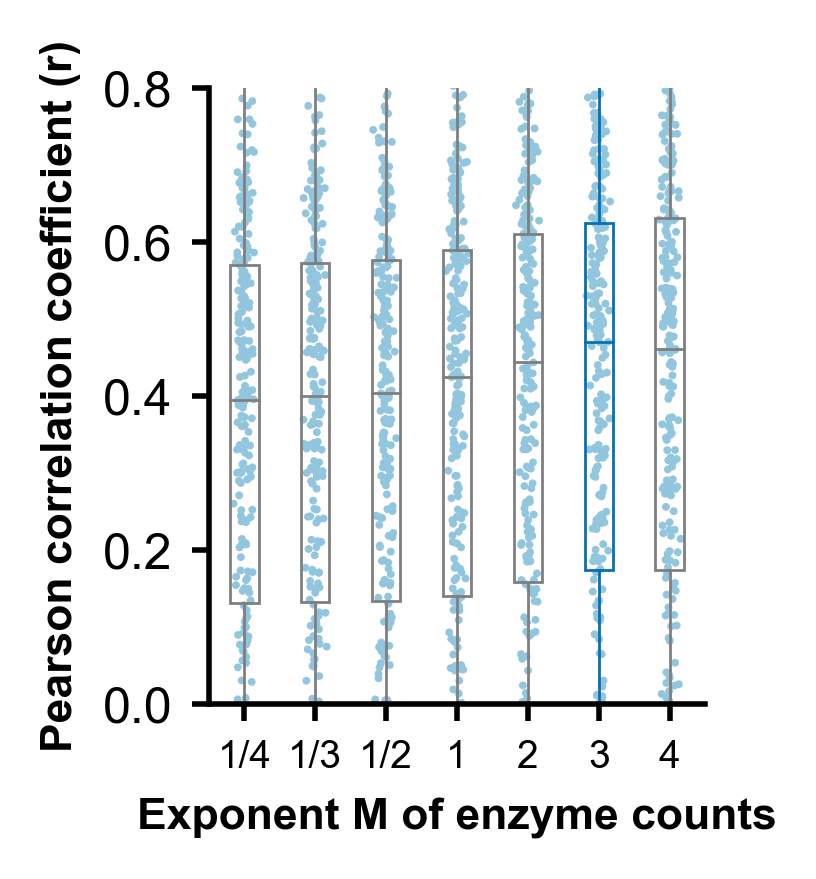

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 数据 =====
rate_labels = [label for label, _ in rate_items]
data = [corr_dict[label] for label in rate_labels]
positions = list(range(1, len(rate_labels) + 1))

# ===== 全局设置（统一风格）=====
np.random.seed(0)

fig, ax = plt.subplots(figsize=(1.6, 2), dpi=400)

plt.rcParams.update({'font.size': 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# ===== violin =====
# vp = ax.violinplot(
#     data,
#     positions=positions,
#     widths=0.7,
#     showmeans=False,
#     showmedians=False,
#     showextrema=False
# )

# for body in vp['bodies']:
#     body.set_facecolor('none')
#     body.set_edgecolor('#0571b0')
#     body.set_linewidth(0.5)
#     body.set_alpha(1)

# ===== boxplot（更轻，不遮挡）=====
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.4,
    patch_artist=True,
    showfliers=False,
    showcaps=False
)

# color = '#0571b0'
# color = 'black'
# # ===== box =====
# for patch in bp['boxes']:
#     patch.set_facecolor('none')
#     patch.set_edgecolor(color)
#     patch.set_linewidth(0.5)

# # ===== whisker =====
# for line in bp['whiskers']:
#     line.set_color(color)
#     line.set_linewidth(0.5)

# # ===== caps（如果你开了的话）=====
# for cap in bp.get('caps', []):
#     cap.set_color(color)
#     cap.set_linewidth(0.5)

# # ===== median =====
# for median in bp['medians']:
#     median.set_color(color)
#     median.set_linewidth(0.5)
    
    
edge_colors = ['#7F7F7F', '#7F7F7F', '#7F7F7F', '#7F7F7F', '#7F7F7F',  '#0571b0', '#7F7F7F']

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_colors[i])
    patch.set_linewidth(0.5)

for i, line in enumerate(bp['whiskers']):
    line.set_color(edge_colors[i//2])
    line.set_linewidth(0.5)

for i, median in enumerate(bp['medians']):
    median.set_color(edge_colors[i])
    median.set_linewidth(0.5)    


# ===== median trend line（新增）=====
median_values = [np.median(group) if len(group) > 0 else np.nan for group in data]
# ax.plot(
#     positions,
#     median_values,
#     color='#ca0020',
#     marker='o',
#     markersize=2.8,
#     linewidth=0.8,
#     zorder=-3
# )
# mean_values = [np.mean(group) if len(group) > 0 else np.nan for group in data]

# ax.plot(
#     positions,
#     mean_values,
#     color='#ca0020',
#     marker='o',
#     markersize=2.8,
#     linewidth=0.8,
#     zorder=3
# )
for i, group in enumerate(data):
    x_jittered = positions[i] + np.random.normal(0, 0.06, size=len(group))
    ax.scatter(
        x_jittered,
        group,
        color='#92c5de',
        edgecolors='none',
        s=2,
        zorder=1,
        alpha=1
    )

# ===== 坐标轴 =====
ax.set_xticks(positions)
ax.set_xticklabels(rate_labels, fontsize=7)

ax.set_xlabel('Exponent M of enzyme counts', fontsize=8, fontweight='bold')
ax.set_ylabel('Pearson correlation coefficient (r)', fontsize=8, fontweight='bold')

# ===== tick风格（统一规范）=====
ax.tick_params(axis='y', direction='out', width=1, length=3)
ax.tick_params(axis='x', direction='out', width=1, length=3)

# ===== 边框 =====
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

plt.ylim(0,0.8)
# ===== 边距 =====
# plt.subplots_adjust(left=0.13, right=0.95, bottom=0.2, top=0.92)

plt.savefig('../../Figure/Figure-2b.pdf', dpi=400, bbox_inches='tight')
plt.show()